# 🧠 System 1: building a "JEV-like" decision model from scratch

**Educational notebook — webinar handout**

We build, piece by piece, a model that receives a **state**, a **question** and a **variable-size list of choices**, and returns **in a single forward pass** a calibrated probability distribution over those choices. No generation, no autoregressive loop, no KV-cache: this is a fast "System 1", meant to serve as a decision module in larger architectures (robotics, ARC-AGI-3 agents, fast trading decisions…).

| Part | Content |
|---|---|
| 0 | Corrections and important clarifications |
| 1 | The idea: a decision = scoring choices in one pass |
| 2 | Setup and configuration |
| 3 | Anatomy of Qwen3-0.6B (and why not Qwen3.5) |
| 4 | Input format: question → state → choices → forced ending |
| 5 | Shared `position_ids`: invariance to order |
| 6 | The 4D attention mask: choices never see each other |
| 7 | Pooling: one vector per choice + one answer vector |
| 8 | No-training tests (shapes, invariance) |
| 9 | Data: schema, procedural generators, augmentation |
| 10 | Decision heads: dot, bilinear, self-attention + bilinear |
| 11 | Per-layer probing, truncation 20/28, LoRA |
| 12 | Training |
| 13 | Validation: accuracy, NLL, Brier, ECE, temperature, invariance, latency |
| 14 | Calibration and RL: what we know, what we propose |
| 15 | Saving, inference, integration (IERM, ARC-AGI-3, trading) |
| A | Appendix: moving to production code with Claude Code |

**Two execution modes**

- `tiny_debug=True` (automatic if no GPU): a **random** mini-Qwen3 (same code, same HF classes, 6 layers of width 128). The whole notebook runs on CPU in a few minutes: perfect for showing tensors, masks and tests live during the webinar. The metrics obviously carry no meaning.
- `tiny_debug=False`: the real `Qwen/Qwen3-0.6B` on GPU (A100/L4/4090…).


## 0. ⚠️ Clarifications (from old version )

A few points from my notes. These are verifiable points, not opinions.

| Note | What is accurate |
|---|---|
| "Qwen 0.6B is like the 0.8B: 1 transformer for 3 linear layers (Gated DeltaNet / Mamba2)" | **No.** `Qwen3-0.6B` is a **pure dense transformer**: 28 layers, all with full softmax attention (GQA 16 Q heads / 8 KV heads, QK-Norm, RoPE). The hybrid layout is **Qwen3.5**'s: the 0.8B follows `6 × (3 × (Gated DeltaNet → FFN) → 1 × (Gated Attention → FFN))`, i.e. 24 layers of which 6 are attention. Gated DeltaNet is not Mamba2: it is a "delta rule" linear attention with gating (a cousin of Mamba2, but a different family). |
| Consequence for a future module on Qwen3.5-4B | **The 4D mask trick + shared `position_ids` does not work on Gated DeltaNet layers**: they are recurrent (a state that updates token after token), with no RoPE and no mask. Concatenated choices would "leak" into each other and invariance to order would disappear. For this module, stick with a **full-attention** backbone (Qwen3 0.6B / 1.7B / 4B). An alternative exists for the hybrid (see §15). |
| "As in RAG, we keep the last hidden state as the representative of the sequence" | **True for a causal decoder**: the last token is the only one that has seen its whole sequence. In RAG it is **depending on the embedder**: CLS or mean-pooling for BERT-style encoders, last-token / EOS for LLM-derived embedders (Qwen3-Embedding, E5-Mistral). |
| "The answer starts at `q_end+2`" | Only correct if every choice is 1 token long. With variable-length choices, the forced ending must start **after the longest choice**: `P + L_max` (P = length of the prefix). Otherwise the answer would have a position *earlier* than some choice tokens it attends to. |
| "Max 255 choices, output head of size 255" | The limit is an **implementation convenience** (padding), not a requirement. With a pairwise score (`answer · W · choice`), the number of choices is free and the head stays **equivariant**. A `Linear(d, 255)` on the answer vector (first version of the video's code) would **break** the invariance: the output index would be tied to the position of the choice. The final code of the video (einsum `bd,bcd->bc`) fixes this. |
| Adding special tokens `[CHOICE]`, `[ANSWER]`… | Trap: with LoRA, the embedding matrix is frozen, so **new** tokens remain random. We use **text markers** here (`Question:`, `- `, `The answer is:`) that the model already knows. The segmentation is carried by our indices, not by tokens. |
| Shuffling choices as augmentation | Pointless if the invariance is exact (that is the whole point). We do keep an automatic invariance **test** though. |
| "Keep 20 layers out of 28" | Plausible intuition, consistent with probing research (middle layers often carry better representations than the last ones, which are specialized in next-token prediction). **To be measured**: §11 provides a per-layer probe. |
| TypeSafe AI / Jev's training method ("RL for calibrated decisions") | Not published to my knowledge; I cannot verify it. We train with cross-entropy (a proper scoring rule → calibration in expectation), we measure calibration, we correct it (temperature), and we propose an RL track (§14).


## 1. The idea: one decision = scoring choices in one pass

Four ways to make an LLM decide among K choices:

| Approach | Passes | Invariant to order? | Are the choices compared? | Remark |
|---|---|---|---|---|
| Free generation ("answer A, B or C") | 1 + decoding | ❌ known position bias | implicitly | slow, fragile parsing, poorly calibrated probabilities |
| LM scoring: log-prob of each choice | K | ✅ if one pass per choice | ❌ | expensive, length bias |
| Cross-encoder (state + 1 choice → score) | K | ✅ | ❌ | no comparison between options |
| **Here: one pass, choices isolated by mask, comparative head** | **1** | ✅ **exact** | ✅ in the head | fast, directly usable probabilities |

```mermaid
flowchart LR
  A["question + state<br/>(prefix, causal)"] --> B1["choice 1<br/>sees prefix"]
  A --> B2["choice 2<br/>sees prefix"]
  A --> B3["choice k<br/>sees prefix"]
  A --> R["forced ending<br/>'The answer is:'<br/>sees EVERYTHING"]
  B1 --> R
  B2 --> R
  B3 --> R
  B1 -- "last hidden" --> H["decision head<br/>(self-attn + bilinear)"]
  B2 -- "last hidden" --> H
  B3 -- "last hidden" --> H
  R -- "last hidden" --> H
  H --> P["P(c1), P(c2), …, P(ck)"]
```

> `mermaid` diagrams render natively in JupyterLab ≥ 4.1 and on GitHub; in VS Code you need a Mermaid extension. The matplotlib figures, on the other hand, display everywhere.


## 2. Setup and configuration

Versions with which this notebook was run end to end (tiny mode, CPU, `sdpa` and `eager`): `torch 2.14`, `transformers 5.18`, `peft 0.21`. The transformers masking API has changed several times: if you change versions, first re-run the §8 tests.


In [1]:
# !pip install -U torch transformers peft accelerate datasets matplotlib
import math, random, time, json, os, copy
from dataclasses import dataclass, asdict
from typing import List, Dict, Optional
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import transformers
from packaging import version

print("torch", torch.__version__, "| transformers", transformers.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.bfloat16 if (DEVICE.type == "cuda" and torch.cuda.is_bf16_supported()) else torch.float32
print("device:", DEVICE, "| dtype backbone:", DTYPE)

torch 2.6.0+cu124 | transformers 5.14.1
device: cuda | dtype backbone: torch.bfloat16


In [2]:
TASKS = ["trade_toy", "math_mc", "intent"]          # types de tâche → "task token" de la tête
TASK2ID = {t: i for i, t in enumerate(TASKS)}

@dataclass
class CFG:
    # --- backbone ---
    model_name: str = "Qwen/Qwen3-0.6B"
    tiny_debug: bool = not torch.cuda.is_available()   # mini-Qwen3 aléatoire pour CPU / démo
    attn_impl: str = "sdpa"           # "sdpa" ou "eager". PAS "flash_attention_2" : il ignore les masques 4D arbitraires
    n_keep_layers: int = 20           # on garde les 20 premières couches sur 28
    # --- LoRA ---
    use_lora: bool = True
    lora_last_n: int = 12             # LoRA sur les 12 dernières couches gardées (8..19)
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.05
    # --- encodage ---
    align: str = "left"               # "left" (vidéo : tous les choix commencent à P) ou "right" (tous finissent à P+Lmax-1)
    max_question_tokens: int = 64
    max_state_tokens: int = 320       # on garde la FIN de l'état (le plus récent)
    max_choice_tokens: int = 24
    max_choices: int = 255
    # --- tête ---
    head_type: str = "attn"           # "dot" | "bilinear" | "attn"
    head_dim: int = 512
    head_layers: int = 2
    head_heads: int = 8
    # --- entraînement ---
    batch_size: int = 16
    epochs: int = 1
    lr_head: float = 3e-4
    lr_lora: float = 1e-4
    weight_decay: float = 0.01
    warmup_ratio: float = 0.05
    label_smoothing: float = 0.0
    grad_clip: float = 1.0
    grad_ckpt: bool = False
    eval_every: int = 300
    n_train: int = 40_000
    n_val: int = 2_000
    n_test: int = 2_000
    use_intent: bool = False          # True = ajoute des exemples MASSIVE (intent) depuis le Hub HF
    seed: int = 0

cfg = CFG()
if cfg.tiny_debug:   # tailles réduites pour CPU
    cfg.n_keep_layers, cfg.lora_last_n = 6, 3
    cfg.head_dim, cfg.head_heads = 64, 4
    cfg.n_train, cfg.n_val, cfg.n_test = 1500, 200, 200
    cfg.eval_every, cfg.batch_size = 50, 16

def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
seed_all(cfg.seed)
print(json.dumps(asdict(cfg), indent=1))

{
 "model_name": "Qwen/Qwen3-0.6B",
 "tiny_debug": false,
 "attn_impl": "sdpa",
 "n_keep_layers": 20,
 "use_lora": true,
 "lora_last_n": 12,
 "lora_r": 16,
 "lora_alpha": 32,
 "lora_dropout": 0.05,
 "align": "left",
 "max_question_tokens": 64,
 "max_state_tokens": 320,
 "max_choice_tokens": 24,
 "max_choices": 255,
 "head_type": "attn",
 "head_dim": 512,
 "head_layers": 2,
 "head_heads": 8,
 "batch_size": 16,
 "epochs": 1,
 "lr_head": 0.0003,
 "lr_lora": 0.0001,
 "weight_decay": 0.01,
 "warmup_ratio": 0.05,
 "label_smoothing": 0.0,
 "grad_clip": 1.0,
 "grad_ckpt": false,
 "eval_every": 300,
 "n_train": 40000,
 "n_val": 2000,
 "n_test": 2000,
 "use_intent": false,
 "seed": 0
}


## 3. Anatomy of Qwen3-0.6B

### 3.1 The spec sheet

| Hyperparameter | Qwen3-0.6B |
|---|---|
| Layers (decoder blocks) | 28, **all full attention** |
| `hidden_size` d | 1024 |
| Q heads / KV heads (GQA) | 16 / 8 → each KV head is shared by 2 Q heads |
| `head_dim` | 128 (hence `q_proj`: 1024 → 16×128 = **2048**, `k_proj`/`v_proj`: 1024 → 8×128 = 1024) |
| MLP | SwiGLU, `intermediate_size` = 3072 |
| Normalization | RMSNorm (pre-norm) + **QK-Norm** (per-head RMSNorm on q and k, a Qwen3 novelty) |
| Positions | RoPE, θ = 1 000 000 |
| Vocabulary | 151 936, embeddings tied to `lm_head` |
| Parameters | ≈ 0.6 B, of which ≈ 0.16 B for the embeddings |

### 3.2 A decoder block

```mermaid
flowchart TB
  x["h  (B, L, 1024)"] --> n1["RMSNorm"]
  n1 --> q["q_proj 1024→2048<br/>16 heads × 128"]
  n1 --> k["k_proj 1024→1024<br/>8 heads × 128"]
  n1 --> v["v_proj 1024→1024"]
  q --> qn["QK-Norm (per-head RMSNorm)"] --> rq["RoPE(position_ids)"]
  k --> kn["QK-Norm (per-head RMSNorm)"] --> rk["RoPE(position_ids)"]
  rq --> att["softmax(QKᵀ/√128 + M) · V<br/>M = 4D additive mask"]
  rk --> att
  v --> att
  att --> o["o_proj 2048→1024"] --> a1(("+"))
  x --> a1
  a1 --> n2["RMSNorm"]
  n2 --> g["gate_proj 1024→3072"] --> s["SiLU"] --> m(("×"))
  n2 --> u["up_proj 1024→3072"] --> m
  m --> d["down_proj 3072→1024"] --> a2(("+"))
  a1 --> a2
  a2 --> y["h'  (B, L, 1024)"]
```

**The only two places where token order matters** are `position_ids` (via RoPE) and the mask `M`. Everything else is applied token by token. That is why controlling these two objects controls exactly "who sees what" and "who is where": this is the core of the method.

### 3.3 And Qwen3.5?

| | Qwen3-0.6B | Qwen3.5-0.8B |
|---|---|---|
| Layers | 28 attention | 24 = 6 × (3 Gated DeltaNet + 1 Gated Attention) |
| Token mixing | maskable softmax(QKᵀ) | 18 recurrent layers (matrix state `S_t`) + 6 attention layers |
| Arbitrary 4D mask / shared positions | ✅ | ❌ on the DeltaNet layers |
| Modalities | text | vision + text |

A Gated DeltaNet layer updates a state `S_t = α_t · S_{t-1}(I − β_t k_t k_tᵀ) + β_t v_t k_tᵀ` and then reads `o_t = S_t q_t`. Token t depends on *all* previous tokens through `S_t`, in order: it is impossible to isolate choice 2 from choice 1 with a mask. Hence the choice of a full-attention backbone for this module.


In [3]:
from transformers import AutoTokenizer, AutoModel, AutoConfig

class CharTokenizer:
    """Tokenizer de secours hors-ligne (1 caractère = 1 token). Uniquement pour le mode tiny."""
    pad_token_id = 0
    def __len__(self): return 260
    def __call__(self, text, add_special_tokens=False):
        return {"input_ids": [min(ord(ch), 255) + 4 for ch in text]}
    def convert_ids_to_tokens(self, ids):
        return [chr(i - 4) if i >= 4 else f"<{i}>" for i in ids]

def load_tokenizer(cfg):
    try:
        tok = AutoTokenizer.from_pretrained(cfg.model_name)
    except Exception as e:
        if not cfg.tiny_debug:
            raise
        print("⚠️ tokenizer HF indisponible → CharTokenizer :", repr(e)[:100])
        tok = CharTokenizer()
    if getattr(tok, "pad_token_id", None) is None:
        tok.pad_token_id = 0
    return tok

def load_backbone(cfg, tok):
    """AutoModel = Qwen3Model : le transformer SANS lm_head (sortie = hidden states)."""
    if cfg.tiny_debug:
        from transformers import Qwen3Config
        conf = Qwen3Config(vocab_size=len(tok), hidden_size=128, intermediate_size=384,
                           num_hidden_layers=8, num_attention_heads=4, num_key_value_heads=2,
                           head_dim=32, max_position_embeddings=4096, rope_theta=1_000_000.0,
                           tie_word_embeddings=True)
        model = AutoModel.from_config(conf, attn_implementation=cfg.attn_impl)
    else:
        kw = {"dtype": DTYPE} if version.parse(transformers.__version__) >= version.parse("4.56") else {"torch_dtype": DTYPE}
        model = AutoModel.from_pretrained(cfg.model_name, attn_implementation=cfg.attn_impl, **kw)
    return model.to(device=DEVICE, dtype=DTYPE)

tok = load_tokenizer(cfg)
PAD_ID = tok.pad_token_id
backbone = load_backbone(cfg, tok)
c = backbone.config
print(type(backbone).__name__, "| attn:", c._attn_implementation)
for k in ["hidden_size", "num_hidden_layers", "num_attention_heads", "num_key_value_heads",
          "head_dim", "intermediate_size", "vocab_size", "rope_theta", "tie_word_embeddings"]:
    print(f"  {k:22s} {getattr(c, k, None)}")
n_tot = sum(p.numel() for p in backbone.parameters())
n_emb = backbone.embed_tokens.weight.numel()
print(f"paramètres : {n_tot/1e6:.1f} M (dont embeddings {n_emb/1e6:.1f} M)")

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[transformers] Qwen3Model LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Qwen3Model | attn: sdpa
  hidden_size            1024
  num_hidden_layers      28
  num_attention_heads    16
  num_key_value_heads    8
  head_dim               128
  intermediate_size      3072
  vocab_size             151936
  rope_theta             None
  tie_word_embeddings    True
paramètres : 596.0 M (dont embeddings 155.6 M)


In [4]:
print(backbone.layers[0])   # un bloc décodeur, tel que défini par transformers

Qwen3DecoderLayer(
  (self_attn): Qwen3Attention(
    (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
    (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
    (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
    (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
    (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
    (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
  )
  (mlp): Qwen3MLP(
    (gate_proj): Linear(in_features=1024, out_features=3072, bias=False)
    (up_proj): Linear(in_features=1024, out_features=3072, bias=False)
    (down_proj): Linear(in_features=3072, out_features=1024, bias=False)
    (act_fn): SiLUActivation()
  )
  (input_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
  (post_attention_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
)


### 3.4 Tracing the tensors through a block

We attach *hooks* to print the shape of each intermediate tensor during one pass. Notice `q_norm`, which operates on `(B, L, heads, head_dim)`: this is where the splitting into heads becomes visible.


In [5]:
@torch.no_grad()
def trace_shapes(model, input_ids):
    L0 = model.layers[0]
    targets = {
        "embed_tokens": model.embed_tokens,
        "L0.input_layernorm": L0.input_layernorm,
        "L0.self_attn.q_proj": L0.self_attn.q_proj,
        "L0.self_attn.k_proj": L0.self_attn.k_proj,
        "L0.self_attn.v_proj": L0.self_attn.v_proj,
        "L0.self_attn.q_norm (par tête)": L0.self_attn.q_norm,
        "L0.self_attn.k_norm (par tête)": L0.self_attn.k_norm,
        "L0.self_attn.o_proj": L0.self_attn.o_proj,
        "L0.mlp.gate_proj": L0.mlp.gate_proj,
        "L0.mlp.up_proj": L0.mlp.up_proj,
        "L0.mlp.down_proj": L0.mlp.down_proj,
        "L0 (sortie du bloc)": L0,
        "norm finale": model.norm,
    }
    logs, hooks = [], []
    def mk(name):
        def hook(mod, inp, out):
            o = out[0] if isinstance(out, (tuple, list)) else out
            logs.append((name, tuple(o.shape)))
        return hook
    for n, m in targets.items():
        hooks.append(m.register_forward_hook(mk(n)))
    try:
        model(input_ids=input_ids, use_cache=False)
    finally:
        for h in hooks: h.remove()
    for n, s in logs:
        print(f"{n:34s} → {s}")

ids = torch.tensor([tok("wake me up at nine am on friday", add_special_tokens=False)["input_ids"]], device=DEVICE)
print("input_ids :", tuple(ids.shape))
trace_shapes(backbone, ids)

input_ids : (1, 8)
embed_tokens                       → (1, 8, 1024)
L0.input_layernorm                 → (1, 8, 1024)
L0.self_attn.q_proj                → (1, 8, 2048)
L0.self_attn.q_norm (par tête)     → (1, 8, 16, 128)
L0.self_attn.k_proj                → (1, 8, 1024)
L0.self_attn.k_norm (par tête)     → (1, 8, 8, 128)
L0.self_attn.v_proj                → (1, 8, 1024)
L0.self_attn.o_proj                → (1, 8, 1024)
L0.mlp.gate_proj                   → (1, 8, 3072)
L0.mlp.up_proj                     → (1, 8, 3072)
L0.mlp.down_proj                   → (1, 8, 1024)
L0 (sortie du bloc)                → (1, 8, 1024)
norm finale                        → (1, 8, 1024)


## 4. Input format: question → state → choices → forced ending

Each example (a "row" of the dataset) has four parts: **state**, **question**, **choices**, **label**. We add the **task type** for the task token of the head.

As in the video, the **question is placed before the state**: the model first reads what is being asked, then the state, which orients the whole reading of the state (in causal mode, the state tokens already "know" which question is being asked). The sequence ends with a **forced ending** `The answer is:` whose last token summarizes "everything that was seen".

```
[Question: … \n][State: … \n][Choices:\n] [- choice_1\n] [- choice_2\n] … [- choice_k\n] [The answer is:]
 └──────────────── prefix P tokens ────┘ └──── k segments isolated from each other ───┘ └─ forced ending ─┘
```

Implementation points:

- each part is tokenized **separately**: we thus know exactly the segment boundaries, with no special tokens;
- the state is truncated **on the left** (we keep the most recent: for a time series or a game history, that is what matters);
- each choice is truncated to `max_choice_tokens` **then** receives its final `\n`: the pooled token is always the same terminator, which has seen the whole choice.


In [6]:
QUESTION_TMPL = "Question: {q}\n"
STATE_TMPL    = "State: {s}\n"
CHOICES_HDR   = "Choices:\n"
ENDING        = "The answer is:"

def toks(text):
    return tok(text, add_special_tokens=False)["input_ids"]

NEWLINE_IDS = toks("\n")

def encode_example(ex, cfg=cfg):
    q_ids = toks(QUESTION_TMPL.format(q=ex["question"]))[: cfg.max_question_tokens]
    s_ids = toks(STATE_TMPL.format(s=ex["state"]))
    if len(s_ids) > cfg.max_state_tokens:
        s_ids = s_ids[-cfg.max_state_tokens:]                 # on garde la fin (le plus récent)
    prefix = q_ids + s_ids + toks(CHOICES_HDR)
    choices = []
    for ch in ex["choices"]:
        body = toks("- " + ch)[: cfg.max_choice_tokens - len(NEWLINE_IDS)]
        choices.append(body + NEWLINE_IDS)
    assert 2 <= len(choices) <= cfg.max_choices, len(choices)
    return {"prefix": prefix, "choices": choices, "ending": toks(ENDING),
            "label": int(ex.get("label", -1)), "task": TASK2ID[ex["task"]]}

demo_ex = {"task": "intent",
           "state": "wake me up at nine am on friday",
           "question": "Which intent best matches this request?",
           "choices": ["alarm_set", "alarm_remove", "alarm_query", "recommendation_events"],
           "label": 0}
demo_enc = encode_example(demo_ex)
print("préfixe :", len(demo_enc["prefix"]), "tokens")
print("choix   :", [len(c) for c in demo_enc["choices"]], "tokens")
print("fin     :", len(demo_enc["ending"]), "tokens")
print(tok.convert_ids_to_tokens(demo_enc["choices"][3]))

préfixe : 22 tokens
choix   : [4, 4, 4, 4] tokens
fin     : 4 tokens
['-', 'Ġrecommendation', '_events', 'Ċ']


## 5. Shared `position_ids`: invariance to order

With P prefix tokens and choices of lengths `ℓ_i`, `L_max = max ℓ_i`:

| Segment | `position_ids` (align = "left", as in the video) | align = "right" (variant) |
|---|---|---|
| prefix | 0 … P−1 | 0 … P−1 |
| choice i | P … P+ℓ_i−1 (**all start at P**) | P+L_max−ℓ_i … P+L_max−1 (**all end at P+L_max−1**) |
| forced ending | P+L_max … | P+L_max … |

Why this is invariant: choice i only sees the prefix and itself, with positions that do not depend on its rank in the list. Its hidden state is therefore identical wherever it is placed. The forced ending sees the **set** {(token, position)} of all the choices; attention being a weighted sum over the keys, it is invariant to their permutation.

`left` vs `right`: with `right`, each choice's pooled token is at the **same distance** from the forced ending (RoPE encodes relative distances), at the price of a "hole" of positions between the prefix and the start of short choices. Both are valid; it is a hyperparameter to compare.

We build the flat sequence and three aligned arrays: `ids`, `pos`, `seg` (segment: 0 = prefix, 1..k = choices, −1 = forced ending, −2 = padding).


In [7]:
PREFIX_SEG, ANS_SEG, PAD_SEG = 0, -1, -2

def build_sequence(enc, align="left"):
    P = len(enc["prefix"])
    L_max = max(len(c) for c in enc["choices"])
    ids, pos, seg = list(enc["prefix"]), list(range(P)), [PREFIX_SEG] * P
    choice_last = []
    for i, c in enumerate(enc["choices"], start=1):
        start = P if align == "left" else P + L_max - len(c)
        ids += c
        pos += list(range(start, start + len(c)))
        seg += [i] * len(c)
        choice_last.append(len(ids) - 1)          # index (dans la séquence plate) du dernier token du choix i
    a0 = P + L_max
    ids += enc["ending"]
    pos += list(range(a0, a0 + len(enc["ending"])))
    seg += [ANS_SEG] * len(enc["ending"])
    return {"ids": ids, "pos": pos, "seg": seg, "choice_last": choice_last, "answer_last": len(ids) - 1}

s = build_sequence(demo_enc)
print("longueur plate :", len(s["ids"]))
print("index poolés choix :", s["choice_last"], "| réponse :", s["answer_last"])
print("pos (fin du préfixe → fin) :", s["pos"][len(demo_enc['prefix']) - 3:])

longueur plate : 42
index poolés choix : [25, 29, 33, 37] | réponse : 41
pos (fin du préfixe → fin) : [19, 20, 21, 22, 23, 24, 25, 22, 23, 24, 25, 22, 23, 24, 25, 22, 23, 24, 25, 26, 27, 28, 29]


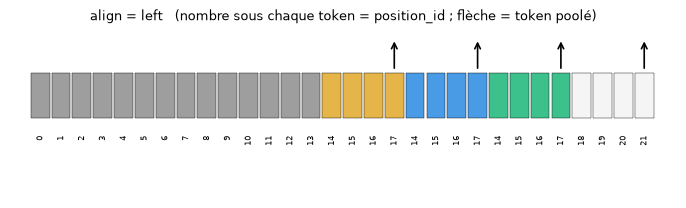

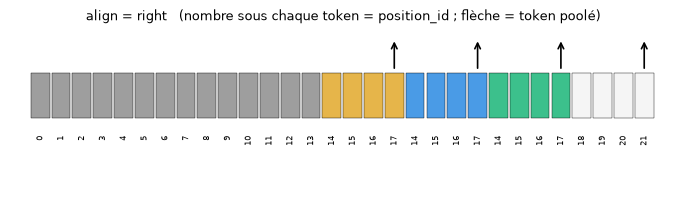

In [8]:
SEG_COLORS = {PREFIX_SEG: "#9e9e9e", ANS_SEG: "#f5f5f5", PAD_SEG: "#000000"}
CHOICE_COLORS = ["#e6b54a", "#4a9be6", "#3cc08c", "#d46ad4", "#e67a4a", "#7a7ae6"]
def seg_color(sg):
    return SEG_COLORS[sg] if sg <= 0 else CHOICE_COLORS[(sg - 1) % len(CHOICE_COLORS)]

def plot_layout(seq, title=""):
    n = len(seq["ids"])
    fig, ax = plt.subplots(figsize=(min(18, 0.22 * n + 2), 2.2))
    for j, (p, sg) in enumerate(zip(seq["pos"], seq["seg"])):
        ax.add_patch(plt.Rectangle((j, 0), 0.9, 0.9, color=seg_color(sg), ec="k", lw=0.3))
        ax.text(j + 0.45, -0.35, str(p), ha="center", va="top", fontsize=6, rotation=90)
    for j in seq["choice_last"] + [seq["answer_last"]]:
        ax.annotate("", xy=(j + 0.45, 0.95), xytext=(j + 0.45, 1.6), arrowprops=dict(arrowstyle="<-", lw=1.2))
    ax.set_xlim(-1, n + 1); ax.set_ylim(-1.6, 1.8); ax.axis("off")
    ax.set_title(title + "   (nombre sous chaque token = position_id ; flèche = token poolé)", fontsize=9)
    plt.show()

short = {"task": "intent", "question": "intent?", "state": "wake me 9am",
         "choices": ["alarm_set", "alarm_remove", "alarm_query"], "label": 0}
enc_short = encode_example(short)
plot_layout(build_sequence(enc_short, "left"), "align = left")
plot_layout(build_sequence(enc_short, "right"), "align = right")

## 6. The 4D attention mask: choices never see each other

Rules (in addition to causality by index in the flat sequence):

| query ↓ / key → | prefix | same choice | other choice | forced ending | padding |
|---|---|---|---|---|---|
| prefix | ✅ | – | – | – | ❌ |
| choice i | ✅ | ✅ | ❌ | – | ❌ |
| forced ending | ✅ | ✅ | ✅ | ✅ | ❌ |
| padding | ❌ | ❌ | ❌ | ❌ | **itself only** |

The last row avoids an entirely masked row (softmax of −∞ everywhere = `NaN`).

**Format expected by transformers**: a 4D mask `(B, 1, L, L)` is passed **as is** to the layers (no causal mask re-generation). It is provided in **additive** form (0 = allowed, `finfo(dtype).min` = forbidden), which works with both `eager` and `sdpa`. `flash_attention_2` does not support such arbitrary masks.


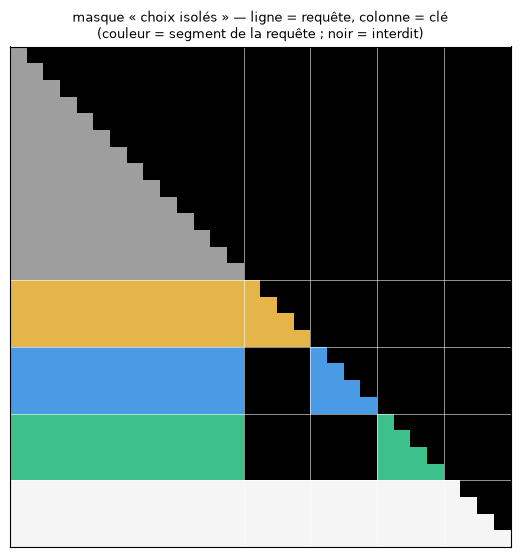

In [9]:
def build_allowed_mask(seg):
    """seg : (B, L) → allowed : (B, L, L) booléen, allowed[b, q, k] = la requête q peut regarder la clé k."""
    B, L = seg.shape
    idx = torch.arange(L, device=seg.device)
    causal = (idx[None, :] <= idx[:, None])[None]          # (1, L, L)  clé ≤ requête
    q, k = seg[:, :, None], seg[:, None, :]
    k_valid = k != PAD_SEG
    rule_prefix = (q == PREFIX_SEG) & (k == PREFIX_SEG)
    rule_choice = (q > 0) & ((k == PREFIX_SEG) | (k == q))
    rule_answer = (q == ANS_SEG) & k_valid
    allowed = causal & (rule_prefix | rule_choice | rule_answer)
    eye = torch.eye(L, dtype=torch.bool, device=seg.device)[None]
    allowed = allowed | (eye & (q == PAD_SEG))               # padding : se voit lui-même → pas de NaN
    return allowed

def additive_mask(allowed, dtype):
    m = torch.zeros(allowed.shape, dtype=dtype, device=allowed.device)
    m.masked_fill_(~allowed, torch.finfo(dtype).min)
    return m[:, None]                                        # (B, 1, L, L) : diffusé sur les têtes

def plot_mask(seq, title="masque"):
    seg = torch.tensor([seq["seg"]])
    A = build_allowed_mask(seg)[0].numpy()
    L = A.shape[0]
    img = np.zeros((L, L, 3))
    for qi in range(L):
        col = np.array(plt.matplotlib.colors.to_rgb(seg_color(seq["seg"][qi])))
        img[qi, A[qi]] = col
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    ax.imshow(img, interpolation="nearest")
    # frontières de segments
    b = [j for j in range(1, L) if seq["seg"][j] != seq["seg"][j - 1]]
    for j in b:
        ax.axhline(j - 0.5, color="w", lw=0.4); ax.axvline(j - 0.5, color="w", lw=0.4)
    ax.set_title(title + " — ligne = requête, colonne = clé\n(couleur = segment de la requête ; noir = interdit)", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    plt.show()

plot_mask(build_sequence(enc_short), "masque « choix isolés »")

### 6.1 Collating a batch

Examples have different lengths and numbers of choices: we **right-pad** the flat sequence, and pad the list of choices up to `K = max k` of the batch, with a boolean `choice_mask`. This is where the "255" limit from the video shows up: it is just a ceiling on `K`.


In [10]:
def collate(encs, align=None, pad_id=None):
    align = align or cfg.align
    pad_id = PAD_ID if pad_id is None else pad_id
    seqs = [build_sequence(e, align) for e in encs]
    B = len(seqs)
    L = max(len(s["ids"]) for s in seqs)
    K = max(len(s["choice_last"]) for s in seqs)
    input_ids = torch.full((B, L), pad_id, dtype=torch.long)
    position_ids = torch.zeros((B, L), dtype=torch.long)
    seg = torch.full((B, L), PAD_SEG, dtype=torch.long)
    choice_idx = torch.zeros((B, K), dtype=torch.long)
    choice_mask = torch.zeros((B, K), dtype=torch.bool)
    answer_idx = torch.zeros(B, dtype=torch.long)
    for i, s in enumerate(seqs):
        n, k = len(s["ids"]), len(s["choice_last"])
        input_ids[i, :n] = torch.tensor(s["ids"])
        position_ids[i, :n] = torch.tensor(s["pos"])
        seg[i, :n] = torch.tensor(s["seg"])
        choice_idx[i, :k] = torch.tensor(s["choice_last"])
        choice_mask[i, :k] = True
        answer_idx[i] = s["answer_last"]
    return {"input_ids": input_ids, "position_ids": position_ids, "seg": seg,
            "allowed": build_allowed_mask(seg), "choice_idx": choice_idx, "choice_mask": choice_mask,
            "answer_idx": answer_idx, "labels": torch.tensor([e["label"] for e in encs]),
            "task": torch.tensor([e["task"] for e in encs])}

def to_device(batch, device=None):
    device = device or DEVICE
    return {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

b = collate([demo_enc, enc_short])
for k, v in b.items():
    print(f"{k:13s} {tuple(v.shape)} {v.dtype}")

input_ids     (2, 42) torch.int64
position_ids  (2, 42) torch.int64
seg           (2, 42) torch.int64
allowed       (2, 42, 42) torch.bool
choice_idx    (2, 4) torch.int64
choice_mask   (2, 4) torch.bool
answer_idx    (2,) torch.int64
labels        (2,) torch.int64
task          (2,) torch.int64


## 7. Pooling: one vector per choice + one answer vector

In a causal decoder, the **last token** of a segment is the only one that has seen the whole segment. We therefore retrieve:

- `choices`: `h[b, choice_idx[b, i]]` → `(B, K, H)`, the last hidden of each choice (which saw prefix + this choice);
- `answer`: `h[b, answer_idx[b]]` → `(B, H)`, the last hidden of the forced ending (which saw everything).

Comparison with RAG: same "last-token pooling" logic as LLM-derived embedders, but here each vector is **conditioned on the question and the state**. That is what makes it a representation of a *decision* and not just of *content*.


In [11]:
def backbone_pool(backbone, batch, output_hidden_states=False):
    dt = next(backbone.parameters()).dtype
    out = backbone(input_ids=batch["input_ids"], position_ids=batch["position_ids"],
                   attention_mask=additive_mask(batch["allowed"], dt), use_cache=False,
                   output_hidden_states=output_hidden_states)
    h = out.last_hidden_state                                       # (B, L, H)
    ar = torch.arange(h.size(0), device=h.device)
    choices = h[ar[:, None], batch["choice_idx"]].float()            # (B, K, H)
    answer = h[ar, batch["answer_idx"]].float()                      # (B, H)
    return choices, answer, out

with torch.no_grad():
    ch, an, _ = backbone_pool(backbone, to_device(collate([demo_enc, enc_short])))
print("choices :", tuple(ch.shape), "| answer :", tuple(an.shape))
print("NaN ?", torch.isnan(ch).any().item(), torch.isnan(an).any().item())

choices : (2, 4, 1024) | answer : (2, 1024)
NaN ? False False


## 8. No-training tests

Before training anything, we check (as in the video) that the machinery does what we think:

1. **Invariance**: we permute the choices, put the vectors back in the original order, and the gap must be ≈ 0 (numerical noise: ~1e-6 in float32, ~1e-2 in bf16).
2. **Counter-example**: with sequential positions and a standard causal mask, the gap must be **large**. If the two tests give the same result, the mask is not being used (wrong `attn_implementation`, transformers version…).


In [12]:
def make_naive(batch):
    """Positions séquentielles + masque causal classique : ce qu'on obtient sans notre astuce."""
    b = dict(batch)
    valid = b["seg"] != PAD_SEG
    L = valid.size(1)
    b["position_ids"] = (valid.long().cumsum(-1) - 1).clamp(min=0)
    causal = torch.tril(torch.ones(L, L, dtype=torch.bool, device=valid.device))[None]
    eye = torch.eye(L, dtype=torch.bool, device=valid.device)[None]
    b["allowed"] = (causal & valid[:, None, :]) | (eye & ~valid[:, :, None])
    return b

def permute_example(ex, perm):
    ex2 = dict(ex)
    ex2["choices"] = [ex["choices"][p] for p in perm]
    if ex.get("label", -1) >= 0:
        ex2["label"] = perm.index(ex["label"])
    if "p_true" in ex:
        ex2["p_true"] = [ex["p_true"][p] for p in perm]
    return ex2

@torch.no_grad()
def invariance_gap(backbone, ex, n_perm=4, naive=False, seed=0):
    rng = random.Random(seed)
    k = len(ex["choices"])
    def reps(e):
        bt = to_device(collate([encode_example(e)]))
        if naive: bt = make_naive(bt)
        c, a, _ = backbone_pool(backbone, bt)
        return c[0], a[0]
    c0, a0 = reps(ex)
    gc, ga = 0.0, 0.0
    for _ in range(n_perm):
        perm = list(range(k)); rng.shuffle(perm)
        c1, a1 = reps(permute_example(ex, perm))
        back = torch.empty_like(c1); back[perm] = c1         # c1[j] = choix d'origine perm[j]
        gc = max(gc, (back - c0).abs().max().item() / (c0.abs().max().item() + 1e-8))
        ga = max(ga, (a1 - a0).abs().max().item() / (a0.abs().max().item() + 1e-8))
    return gc, ga

for naive in [False, True]:
    gc, ga = invariance_gap(backbone, demo_ex, naive=naive)
    print(f"{'NAÏF (causal standard)' if naive else 'NOTRE masque':24s} écart relatif choix={gc:.2e}  réponse={ga:.2e}")

NOTRE masque             écart relatif choix=1.38e-02  réponse=2.79e-02
NAÏF (causal standard)   écart relatif choix=3.00e-01  réponse=7.64e-02


## 9. Data

### 9.1 Schema

One row = one dict (or one JSONL line), and the rest of the pipeline asks for nothing more:

```json
{"task": "trade_toy",
 "question": "Which action should the agent take now?",
 "state": "BTC-PERP 1h | ret_24h=+2.1% | rsi14=64 | funding=+0.012% | position=flat",
 "choices": ["open_long", "hold", "open_short"],
 "label": 0,
 "p_true": [0.61, 0.27, 0.12]}
```

`p_true` is optional: it only exists for **procedural** data where we know the true distribution, which allows measuring calibration *against the truth* and not only against noisy labels.

### 9.2 Three data sources

| Source | Example | Advantage | Risk |
|---|---|---|---|
| **Procedural** | hidden rules, simulator, game, robot environment | infinite volume, known truth, controllable difficulty | the model learns the generator, not the world |
| **Real, annotated** | intents (MASSIVE/SLURP, cf. the `alarm_set` example), MCQ, decision logs | realism | little explicit wrong choices |
| **Augmented** | real + generated distractors | "hard negatives" | distractors too easy or ambiguous |

Augmentations that are truly useful here:

- **variable number of choices** (2…6 at training): the model must not get used to a fixed K; we then test with larger K;
- **hard negatives**: close distractors (same domain, same intent prefix, ±1 on a number…);
- **LLM-generated distractors**, with a check (a judge or a rule) that they are indeed wrong;
- *no* need to permute the choices: the invariance is architectural.

### 9.3 Procedural generators

1. `trade_toy`: a **stochastic** trading toy. A hidden signal combines 24h return, RSI and funding; the true policy is a softmax of utilities; the label is **drawn** from this distribution. The best possible classifier therefore does not go above the "Bayes precision", and the ideal target is `p_true`: excellent for learning to read calibration curves. **This is not a trading strategy.**
2. `math_mc`: deterministic arithmetic MCQ, with "plausible" distractors (±1, ±10, reversed digits, wrong operator) and an adjustable number of choices.


In [13]:
def softmax_np(u):
    e = np.exp(u - u.max()); return e / e.sum()

def gen_trade(rng):
    ret = rng.gauss(0, 3.0)                                  # rendement 24 h en %
    rsi = min(95.0, max(5.0, 50 + 5 * ret + rng.gauss(0, 10)))
    funding = rng.gauss(0, 0.02)                             # en %
    pos = rng.choice(["flat", "long", "short"])
    signal = 0.5 * ret - 0.04 * (rsi - 50) - 20 * funding    # > 0 : haussier (règle cachée)
    if pos == "flat":
        util = {"open_long": signal, "open_short": -signal, "hold": 0.3}
    elif pos == "long":
        util = {"hold": 0.3 + 0.5 * signal, "close_position": -signal, "open_short": -signal - 0.5}
    else:
        util = {"hold": 0.3 - 0.5 * signal, "close_position": signal, "open_long": signal - 0.5}
    choices = list(util); rng.shuffle(choices)
    p = softmax_np(2.0 * np.array([util[c] for c in choices]))
    label = rng.choices(range(len(choices)), weights=p)[0]
    state = f"BTC-PERP 1h | ret_24h={ret:+.1f}% | rsi14={rsi:.0f} | funding={funding:+.3f}% | position={pos}"
    return {"task": "trade_toy", "question": "Which action should the agent take now?", "state": state,
            "choices": choices, "label": label, "p_true": p.tolist(),
            "meta": {"signal": signal, "pos": pos}}

def gen_math(rng, k_range=(2, 6)):
    a, b = rng.randint(2, 99), rng.randint(2, 99)
    op = rng.choice(["+", "-", "*"])
    ans = a + b if op == "+" else a - b if op == "-" else a * b
    pool = {ans + d for d in (1, -1, 2, -2, 10, -10, 11, -11, 100, -100)}
    pool |= {a + b, a - b, b - a, a * b}
    rev = int(str(abs(ans))[::-1]) * (1 if ans >= 0 else -1)
    pool.add(rev); pool.discard(ans)
    k = rng.randint(*k_range)
    distract = rng.sample(sorted(pool), min(k - 1, len(pool)))
    choices = [str(x) for x in [ans] + distract]; rng.shuffle(choices)
    return {"task": "math_mc", "question": f"What is {a} {op} {b}?", "state": "arithmetic, integers",
            "choices": choices, "label": choices.index(str(ans))}

rng = random.Random(0)
print(json.dumps(gen_trade(rng), indent=1))
print(json.dumps(gen_math(rng), indent=1))

{
 "task": "trade_toy",
 "question": "Which action should the agent take now?",
 "state": "BTC-PERP 1h | ret_24h=+2.8% | rsi14=50 | funding=-0.014% | position=short",
 "choices": [
  "hold",
  "open_long",
  "close_position"
 ],
 "label": 2,
 "p_true": [
  0.008599245809358128,
  0.26662872797931636,
  0.7247720262113255
 ],
 "meta": {
  "signal": 1.6780608853244263,
  "pos": "short"
 }
}
{
 "task": "math_mc",
 "question": "What is 40 - 63?",
 "state": "arithmetic, integers",
 "choices": [
  "-32",
  "77",
  "-33",
  "-13",
  "-25",
  "-23"
 ],
 "label": 5
}


### 9.4 Real data: MASSIVE intents (optional)

The "wake me up at nine am on friday → alarm_set" example comes from this kind of intent corpus. The loader below builds MCQs with **hard negatives** (intents from the same scenario: `alarm_*`, `play_*`…). It is disabled by default (`cfg.use_intent`) so that the notebook runs offline; the dataset name on the Hub may evolve, hence the defensive code.


In [14]:
def load_intent_examples(n, rng, k_range=(2, 6), hub_id="mteb/amazon_massive_intent", config="en"):
    from datasets import load_dataset
    ds = load_dataset(hub_id, config, split="train")
    cols = ds.column_names
    text_col = "text" if "text" in cols else "utt"
    if "label_text" in cols:
        labels = ds["label_text"]
    else:
        names = ds.features["label"].names
        labels = [names[i] for i in ds["label"]]
    all_intents = sorted(set(labels))
    by_scen = {}
    for it in all_intents:
        by_scen.setdefault(it.split("_")[0], []).append(it)
    idx = list(range(len(ds))); rng.shuffle(idx)
    out = []
    for i in idx[:n]:
        gold = labels[i]
        k = rng.randint(*k_range)
        hard = [x for x in by_scen[gold.split("_")[0]] if x != gold]
        rest = [x for x in all_intents if x != gold and x not in hard]
        neg = rng.sample(hard, min(len(hard), (k - 1 + 1) // 2))
        neg += rng.sample(rest, k - 1 - len(neg))
        choices = [gold] + neg; rng.shuffle(choices)
        out.append({"task": "intent", "question": "Which intent best matches this request?",
                    "state": ds[i][text_col], "choices": choices, "label": choices.index(gold)})
    return out

# Prompt type pour générer des distracteurs avec un LLM (à vérifier ensuite par une règle ou un juge) :
DISTRACTOR_PROMPT = """You create hard multiple-choice distractors.
State: {state}
Question: {question}
Correct answer: {gold}
Write {n} answers that are plausible but definitely WRONG for this state. One per line, no numbering."""

In [15]:
def build_splits(cfg):
    rng = random.Random(cfg.seed)
    def mix(n, k_range=(2, 6)):
        out = []
        for _ in range(n):
            out.append(gen_trade(rng) if rng.random() < 0.5 else gen_math(rng, k_range))
        return out
    train, val, test = mix(cfg.n_train), mix(cfg.n_val), mix(cfg.n_test)
    if cfg.use_intent:
        intents = load_intent_examples(cfg.n_train // 3 + cfg.n_val + cfg.n_test, rng)
        train += intents[: cfg.n_train // 3]
        val += intents[cfg.n_train // 3: cfg.n_train // 3 + cfg.n_val]
        test += intents[cfg.n_train // 3 + cfg.n_val:]
        rng.shuffle(train)
    # test de généralisation : plus de choix qu'à l'entraînement
    test_bigk = [gen_math(rng, k_range=(7, 10)) for _ in range(max(100, cfg.n_test // 4))]
    return train, val, test, test_bigk

train_ex, val_ex, test_ex, test_bigk_ex = build_splits(cfg)
t0 = time.time()
train_enc = [encode_example(e) for e in train_ex]
val_enc = [encode_example(e) for e in val_ex]
test_enc = [encode_example(e) for e in test_ex]
bigk_enc = [encode_example(e) for e in test_bigk_ex]
lens = [len(build_sequence(e)["ids"]) for e in train_enc[:500]]
print(f"{len(train_enc)} train / {len(val_enc)} val / {len(test_enc)} test / {len(bigk_enc)} test K∈[7,10]"
      f" — encodés en {time.time()-t0:.1f}s ; longueur plate moyenne {np.mean(lens):.0f}, max {max(lens)}")

40000 train / 2000 val / 2000 test / 500 test K∈[7,10] — encodés en 13.7s ; longueur plate moyenne 57, max 70


> **For your real DeFi / trading data**: split train/val/test **in time** (never a random mixing of dates), avoid any future information leak in the state, and validate with out-of-sample backtesting with fees and slippage. A good classification score does not imply a profitable strategy.

## 10. Decision heads

The three variants from the video, all **equivariant** (permuting the choices permutes the scores, nothing else):

| Head | Score of choice i | Parameters | Do the choices compare? |
|---|---|---|---|
| `dot` | `cos(a, c_i) · τ` | 1 (τ) | ❌ — useful as a no-training test |
| `bilinear` | `aᵀ W c_i`, with `W = UᵀV` of rank d | 2·H·d | ❌ |
| `attn` (video, "way three") | self-attention (2 layers) on `[task, c_1…c_k, a]` **without position encoding**, then bilinear | ~ a few M | ✅ |

Why "bilinear = two projections + dot product": `(U a)·(V c) = aᵀ UᵀV c`. A full `H×H` matrix would cost 1 M parameters for H = 1024; the rank-d factorization is lighter and regularizes.

Two additions compared to the video's code:

- a **role embedding** (choice / answer) added before the self-attention, so the head knows which vector is the answer. It is identical for all choices, so the equivariance is preserved;
- the **task token** at the head of the sequence, as in the video: the head knows whether it is ruling on an intent question, a math question or a trading one.

The logits of padding choices are set to `−∞`, so their softmax probability is exactly 0.


In [16]:
class DotHead(nn.Module):
    def __init__(self, hidden, **_):
        super().__init__()
        self.log_tau = nn.Parameter(torch.tensor(math.log(10.0)))
    def forward(self, choices, answer, choice_mask, task=None):
        s = torch.einsum("bd,bkd->bk", F.normalize(answer, dim=-1), F.normalize(choices, dim=-1))
        return (s * self.log_tau.exp()).masked_fill(~choice_mask, float("-inf"))

class BilinearHead(nn.Module):
    def __init__(self, hidden, d=512, **_):
        super().__init__()
        self.norm = nn.LayerNorm(hidden)
        self.U, self.V = nn.Linear(hidden, d), nn.Linear(hidden, d)
        self.d = d
    def forward(self, choices, answer, choice_mask, task=None):
        a, c = self.U(self.norm(answer)), self.V(self.norm(choices))
        s = torch.einsum("bd,bkd->bk", a, c) / math.sqrt(self.d)
        return s.masked_fill(~choice_mask, float("-inf"))

class Block(nn.Module):
    """Bloc transformer pré-norm, SANS encodage de position → équivariant par permutation."""
    def __init__(self, d, n_heads, mlp_ratio=4, dropout=0.0):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, n_heads, dropout=dropout, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(d, mlp_ratio * d), nn.GELU(), nn.Linear(mlp_ratio * d, d))
    def forward(self, x, key_pad):
        h = self.n1(x)
        x = x + self.attn(h, h, h, key_padding_mask=key_pad, need_weights=False)[0]
        return x + self.mlp(self.n2(x))

class AttnHead(nn.Module):
    def __init__(self, hidden, d=512, n_layers=2, n_heads=8, n_tasks=len(TASKS), **_):
        super().__init__()
        self.inp = nn.Sequential(nn.LayerNorm(hidden), nn.Linear(hidden, d))
        self.task_emb = nn.Embedding(n_tasks, d)
        self.role_emb = nn.Embedding(2, d)                     # 0 = choix, 1 = réponse
        self.blocks = nn.ModuleList([Block(d, n_heads) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d)
        self.answer_proj, self.choice_proj = nn.Linear(d, d), nn.Linear(d, d)
        self.d = d
    def forward(self, choices, answer, choice_mask, task):
        B, K, _ = choices.shape
        c = self.inp(choices) + self.role_emb.weight[0]
        a = self.inp(answer)[:, None] + self.role_emb.weight[1]
        t = self.task_emb(task)[:, None]
        x = torch.cat([t, c, a], dim=1)                          # (B, 1+K+1, d)
        ones = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
        key_pad = torch.cat([ones, ~choice_mask, ones], dim=1)   # True = ignorer
        for blk in self.blocks:
            x = blk(x, key_pad)
        x = self.norm(x)
        a = self.answer_proj(x[:, -1])
        c = self.choice_proj(x[:, 1:-1])
        s = torch.einsum("bd,bkd->bk", a, c) / math.sqrt(self.d)
        return s.masked_fill(~choice_mask, float("-inf"))

def make_head(cfg, hidden):
    H = {"dot": DotHead, "bilinear": BilinearHead, "attn": AttnHead}[cfg.head_type]
    return H(hidden, d=cfg.head_dim, n_layers=cfg.head_layers, n_heads=cfg.head_heads).to(DEVICE)

# Test d'équivariance des têtes sur des tenseurs aléatoires
Hd = backbone.config.hidden_size
for name in ["dot", "bilinear", "attn"]:
    head = {"dot": DotHead, "bilinear": BilinearHead, "attn": AttnHead}[name](Hd, d=64, n_heads=4).to(DEVICE).eval()
    ch_, an_ = torch.randn(2, 5, Hd, device=DEVICE), torch.randn(2, Hd, device=DEVICE)
    m_ = torch.tensor([[1, 1, 1, 1, 1], [1, 1, 1, 0, 0]], dtype=torch.bool, device=DEVICE)
    t_ = torch.tensor([0, 1], device=DEVICE)
    perm = torch.tensor([2, 0, 1, 3, 4], device=DEVICE)      # ne bouge pas le padding du 2e exemple
    with torch.no_grad():
        s1 = head(ch_, an_, m_, t_); s2 = head(ch_[:, perm], an_, m_[:, perm], t_)
    ok = torch.allclose(s1[:, perm][m_[:, perm]], s2[m_[:, perm]], atol=1e-5)
    print(f"{name:9s} équivariant : {ok} | P(padding) = {torch.softmax(s1, -1)[1, 3:].tolist()}")

dot       équivariant : True | P(padding) = [0.0, 0.0]
bilinear  équivariant : True | P(padding) = [0.0, 0.0]
attn      équivariant : True | P(padding) = [0.0, 0.0]


### 10.1 The full model

In [17]:
class DecisionModel(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone, self.head = backbone, head
    def forward(self, batch):
        choices, answer, _ = backbone_pool(self.backbone, batch)
        return self.head(choices, answer, batch["choice_mask"], batch["task"])   # (B, K) logits

def decision_loss(logits, labels, choice_mask, eps=0.0):
    """Entropie croisée sur les choix valides, avec label smoothing restreint aux choix valides."""
    logp = F.log_softmax(logits, dim=-1)
    nll = -logp.gather(1, labels[:, None]).squeeze(1)
    if eps > 0:
        smooth = -(logp.masked_fill(~choice_mask, 0.0).sum(-1) / choice_mask.sum(-1))
        nll = (1 - eps) * nll + eps * smooth
    return nll.mean()

# Test « zéro entraînement » : la tête dot sur le backbone brut (s'attendre à ~ hasard)
zs = DecisionModel(backbone, DotHead(Hd).to(DEVICE)).eval()
with torch.no_grad():
    bt = to_device(collate(val_enc[:16]))
    lg = zs(bt)
print("logits :", tuple(lg.shape), "| loss :", decision_loss(lg, bt["labels"], bt["choice_mask"]).item())
print("probas ex. 0 :", torch.softmax(lg[0], -1).cpu().numpy().round(3))

logits : (16, 6) | loss : 1.4225564002990723
probas ex. 0 : [0.212 0.203 0.189 0.179 0.217 0.   ]


## 11. Which layer? Truncation and LoRA

### 11.1 Per-layer probe

To **measure** rather than assume that layer 20 is a good exit point: we freeze the backbone, extract the vectors (choices, answer) **at each layer** (`output_hidden_states=True`), and train a small bilinear head per layer. The accuracy-vs-layer curve shows where decision information is most linearly accessible.

Note: in HF, `hidden_states[0]` = output of the embeddings, `hidden_states[l]` = output of block l, and the **last** one includes the final norm.


In [18]:
@torch.no_grad()
def collect_layer_feats(backbone, encs, bs=16):
    K = max(len(e["choices"]) for e in encs)
    C, A, M, Y = None, None, [], []
    for i in range(0, len(encs), bs):
        bt = to_device(collate(encs[i:i + bs]))
        _, _, out = backbone_pool(backbone, bt, output_hidden_states=True)
        hs = out.hidden_states
        ar = torch.arange(bt["input_ids"].size(0), device=DEVICE)
        kb = bt["choice_idx"].size(1)
        cs = torch.stack([h[ar[:, None], bt["choice_idx"]] for h in hs], 0).half().cpu()   # (nL, B, kb, H)
        cs = F.pad(cs, (0, 0, 0, K - kb))
        an = torch.stack([h[ar, bt["answer_idx"]] for h in hs], 0).half().cpu()           # (nL, B, H)
        C = cs if C is None else torch.cat([C, cs], 1)
        A = an if A is None else torch.cat([A, an], 1)
        M.append(F.pad(bt["choice_mask"].cpu(), (0, K - kb))); Y.append(bt["labels"].cpu())
    return C, A, torch.cat(M), torch.cat(Y)

def probe_layer(c, a, m, y, steps=150, d=128):
    n = len(y) // 2
    head = BilinearHead(c.size(-1), d=d).to(DEVICE)
    opt = torch.optim.Adam(head.parameters(), lr=1e-3)
    c, a, m, y = c.float().to(DEVICE), a.float().to(DEVICE), m.to(DEVICE), y.to(DEVICE)
    for _ in range(steps):
        loss = decision_loss(head(c[:n], a[:n], m[:n]), y[:n], m[:n])
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        return (head(c[n:], a[n:], m[n:]).argmax(-1) == y[n:]).float().mean().item()

N_PROBE = 200 if cfg.tiny_debug else 1500
C, A, M, Y = collect_layer_feats(backbone, train_enc[:N_PROBE])
accs = [probe_layer(C[l], A[l], M, Y) for l in range(C.size(0))]
plt.figure(figsize=(7, 3)); plt.plot(range(len(accs)), accs, "o-")
plt.axvline(cfg.n_keep_layers, ls="--", c="gray", label=f"n_keep_layers = {cfg.n_keep_layers}")
plt.xlabel("couche (0 = embeddings)"); plt.ylabel("précision sonde"); plt.legend(); plt.title("Sonde bilinéaire par couche (backbone gelé)")
plt.show()
del C, A

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 23.67 GiB of which 3.00 MiB is free. Process 3715942 has 22.05 GiB memory in use. Including non-PyTorch memory, this process has 1.52 GiB memory in use. Of the allocated memory 1.25 GiB is allocated by PyTorch, and 20.51 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### 11.2 Truncation

We cut the layers beyond `n_keep_layers`: less compute (≈ −28 % here) and, following the video's intuition, less specialized "next-token" representations. Qwen's final norm is kept (a plain RMSNorm); the head has its own normalization anyway.

### 11.3 LoRA

Training only the head leaves the backbone frozen: the representations do not adapt to the task. LoRA adds to each targeted projection a rank-r update, `W' = W + (α/r)·BA`, with `B` initialized to 0 (the starting model is unchanged at step 0). We apply it to the **last 12 kept layers** (8…19), on the 7 projections of each block (q, k, v, o, gate, up, down). Slower per step, but learns much better (+10 points in the video).

```mermaid
flowchart LR
  E["embeddings<br/>frozen"] --> L0["layers 0…7<br/>frozen"] --> L8["layers 8…19<br/>frozen + LoRA r=16"] --> X["layers 20…27<br/>REMOVED"]
  L8 --> P["pooling"] --> H["attn head<br/>trained"]
```


In [ ]:
def truncate_layers(backbone, n):
    backbone.layers = backbone.layers[:n]
    backbone.config.num_hidden_layers = n
    if getattr(backbone.config, "layer_types", None):
        backbone.config.layer_types = backbone.config.layer_types[:n]
    return backbone

def apply_lora(backbone, cfg):
    for p in backbone.parameters():
        p.requires_grad_(False)
    if not cfg.use_lora:
        return backbone
    from peft import LoraConfig, get_peft_model
    n = len(backbone.layers)
    lcfg = LoraConfig(r=cfg.lora_r, lora_alpha=cfg.lora_alpha, lora_dropout=cfg.lora_dropout, bias="none",
                      target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
                      layers_to_transform=list(range(n - cfg.lora_last_n, n)), layers_pattern="layers")
    pm = get_peft_model(backbone, lcfg)
    pm.print_trainable_parameters()
    return pm

backbone = truncate_layers(backbone, cfg.n_keep_layers)
if cfg.grad_ckpt:
    backbone.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
backbone = apply_lora(backbone, cfg)
model = DecisionModel(backbone, make_head(cfg, Hd))
n_head = sum(p.numel() for p in model.head.parameters())
n_train_bb = sum(p.numel() for p in model.backbone.parameters() if p.requires_grad)
print(f"couches gardées : {cfg.n_keep_layers} | tête : {n_head/1e6:.2f} M | LoRA : {n_train_bb/1e6:.2f} M paramètres entraînables")
print("invariance après troncature + LoRA :", invariance_gap(model.backbone, demo_ex))

## 12. Training

- **Loss**: cross-entropy over the valid choices (proper scoring rule: it is minimized in expectation by the true probabilities, which pushes toward calibration). Optional label smoothing, restricted to the valid choices.
- **Optimizer**: AdamW with **two learning rates** — head (3e-4, initialized with zero knowledge) and LoRA (1e-4, perturbing a pretrained model).
- **Schedule**: linear warmup then cosine.
- **Precision**: backbone in bf16, LoRA adapters and head in float32 (peft handles the conversion), no autocast needed.
- **Indicative budget**: the video quotes ~24 h on an A100 (≈ $36) for the full training. Start with a few thousand steps and look at the validation curves.

Efficiency tip (not implemented, to stay readable): grouping examples of similar lengths in the same batch (bucketing) greatly reduces padding.


In [ ]:
from torch.utils.data import DataLoader
from transformers import get_cosine_schedule_with_warmup

@torch.no_grad()
def predict(model, encs, bs=32):
    model.eval()
    out = []
    for i in range(0, len(encs), bs):
        bt = to_device(collate(encs[i:i + bs]))
        lg = model(bt).float().cpu(); m = bt["choice_mask"].cpu()
        out += [lg[j, : int(m[j].sum())] for j in range(lg.size(0))]
    return out                                                   # liste de tenseurs (k_i,)

def quick_eval(model, encs):
    lgs = predict(model, encs)
    y = [e["label"] for e in encs]
    acc = np.mean([int(l.argmax()) == t for l, t in zip(lgs, y)])
    nll = np.mean([-torch.log_softmax(l, -1)[t].item() for l, t in zip(lgs, y)])
    return acc, nll

def train(model, train_enc, val_enc, cfg):
    head_p = [p for p in model.head.parameters() if p.requires_grad]
    lora_p = [p for p in model.backbone.parameters() if p.requires_grad]
    groups = [{"params": head_p, "lr": cfg.lr_head}] + ([{"params": lora_p, "lr": cfg.lr_lora}] if lora_p else [])
    opt = torch.optim.AdamW(groups, weight_decay=cfg.weight_decay)
    dl = DataLoader(train_enc, batch_size=cfg.batch_size, shuffle=True, collate_fn=collate, num_workers=0)
    total = cfg.epochs * len(dl)
    sched = get_cosine_schedule_with_warmup(opt, int(cfg.warmup_ratio * total), total)
    hist = {"step": [], "loss": [], "val_step": [], "val_acc": [], "val_nll": []}
    step, t0, run = 0, time.time(), []
    for ep in range(cfg.epochs):
        for bt in dl:
            model.train()
            bt = to_device(bt)
            loss = decision_loss(model(bt), bt["labels"], bt["choice_mask"], cfg.label_smoothing)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(head_p + lora_p, cfg.grad_clip)
            opt.step(); sched.step(); step += 1
            run.append(loss.item())
            if step % 10 == 0:
                hist["step"].append(step); hist["loss"].append(np.mean(run[-10:]))
            if step % cfg.eval_every == 0 or step == total:
                acc, nll = quick_eval(model, val_enc)
                hist["val_step"].append(step); hist["val_acc"].append(acc); hist["val_nll"].append(nll)
                print(f"step {step:5d}/{total} | loss {np.mean(run[-50:]):.4f} | val acc {acc:.3f} nll {nll:.4f} | {time.time()-t0:.0f}s")
    return hist

hist = train(model, train_enc, val_enc, cfg)
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(hist["step"], hist["loss"]); ax[0].set_title("loss train"); ax[0].set_xlabel("step")
ax[1].plot(hist["val_step"], hist["val_acc"], "o-"); ax[1].set_title("précision val"); ax[1].set_xlabel("step")
plt.show()

## 13. Validation

A decision model is judged on **five axes**, not only accuracy:

| Axis | Metric | Question |
|---|---|---|
| Correctness | accuracy, NLL | does it pick the right choice? |
| Calibration | **ECE**, Brier, reliability diagram | when it says 80 %, is it right 80 % of the time? |
| Ground truth (procedural) | KL(p_true ‖ p_model), Bayes accuracy | does it approach the true distribution? |
| Invariance / generalization | gap under permutation, accuracy at K larger than at training | does the structure hold? |
| Cost | latency of one decision, throughput | is it really a System 1? |

**ECE** (Expected Calibration Error): we sort the predictions by confidence (probability of the chosen choice) into 15 intervals, and take the weighted average of |accuracy − confidence| per interval.

**Multi-class Brier**: Σ_i (p_i − y_i)², another proper scoring rule, bounded.

**Temperature**: we find the T > 0 minimizing the NLL on the validation set and divide the logits by T. It never changes the argmax (hence the accuracy), and corrects global over- or under-confidence. To be applied on a set distinct from the test.


In [ ]:
def pad_logits(lgs, fill=-1e4):
    # valeur FINIE pour le padding : avec -inf, d(x/T)/dT = inf·0 = NaN dans LBFGS
    K = max(len(l) for l in lgs)
    out = torch.full((len(lgs), K), fill)
    for i, l in enumerate(lgs): out[i, : len(l)] = l
    return out

def fit_temperature(lgs, labels):
    X, y = pad_logits(lgs), torch.tensor(labels)
    logT = torch.zeros(1, requires_grad=True)
    opt = torch.optim.LBFGS([logT], lr=0.1, max_iter=200)
    def closure():
        opt.zero_grad(); loss = F.cross_entropy(X / logT.exp(), y); loss.backward(); return loss
    opt.step(closure)
    return logT.exp().item()

def calib_metrics(lgs, exs, T=1.0, n_bins=15):
    y = np.array([e["label"] for e in exs])
    P = [torch.softmax(l / T, -1).numpy() for l in lgs]
    pred = np.array([p.argmax() for p in P]); conf = np.array([p.max() for p in P])
    correct = (pred == y).astype(float)
    nll = np.mean([-np.log(max(p[t], 1e-12)) for p, t in zip(P, y)])
    brier = np.mean([((p - np.eye(len(p))[t]) ** 2).sum() for p, t in zip(P, y)])
    bins = np.minimum((conf * n_bins).astype(int), n_bins - 1)
    ece, rel = 0.0, []
    for b in range(n_bins):
        m = bins == b
        if m.any():
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
            rel.append((conf[m].mean(), correct[m].mean(), m.sum()))
    res = {"n": len(y), "acc": float(correct.mean()), "nll": float(nll), "brier": float(brier), "ece": float(ece)}
    if all("p_true" in e for e in exs):
        PT = [np.array(e["p_true"]) for e in exs]
        res["kl_true"] = float(np.mean([(pt * (np.log(pt + 1e-12) - np.log(p + 1e-12))).sum() for pt, p in zip(PT, P)]))
        res["acc_bayes"] = float(np.mean([pt.max() for pt in PT]))                 # meilleur possible en espérance
        res["acc_expected"] = float(np.mean([pt[p.argmax()] for pt, p in zip(PT, P)]))
    return res, rel

def report(lgs, exs, T=1.0, title=""):
    print(f"── {title} (T={T:.2f})")
    for task in sorted(set(e["task"] for e in exs)):
        idx = [i for i, e in enumerate(exs) if e["task"] == task]
        r, _ = calib_metrics([lgs[i] for i in idx], [exs[i] for i in idx], T)
        print(f"  {task:10s} " + " | ".join(f"{k} {v:.4f}" if isinstance(v, float) else f"{k} {v}" for k, v in r.items()))

def reliability_plot(lgs, exs, Ts=(1.0,), title=""):
    plt.figure(figsize=(4.5, 4.5)); plt.plot([0, 1], [0, 1], "k--", lw=0.8)
    for T in Ts:
        r, rel = calib_metrics(lgs, exs, T)
        xs, ys, ns = zip(*rel)
        plt.plot(xs, ys, "o-", label=f"T={T:.2f}  ECE={r['ece']:.3f}")
    plt.xlabel("confiance"); plt.ylabel("précision observée"); plt.title(title); plt.legend(); plt.show()

val_lgs, test_lgs = predict(model, val_enc), predict(model, test_enc)
T_star = fit_temperature(val_lgs, [e["label"] for e in val_ex])
report(test_lgs, test_ex, 1.0, "test brut")
report(test_lgs, test_ex, T_star, "test après température (ajustée sur val)")
reliability_plot(test_lgs, test_ex, (1.0, T_star), "Diagramme de fiabilité (test)")

In [ ]:
# Invariance du modèle complet + généralisation à plus de choix + latence
@torch.no_grad()
def permutation_consistency(model, exs, n=100, seed=0):
    rng = random.Random(seed); gaps = []
    for ex in exs[:n]:
        k = len(ex["choices"]); perm = list(range(k)); rng.shuffle(perm)
        p0 = torch.softmax(predict(model, [encode_example(ex)])[0], -1)
        p1 = torch.softmax(predict(model, [encode_example(permute_example(ex, perm))])[0], -1)
        back = torch.empty_like(p1); back[perm] = p1
        gaps.append((back - p0).abs().max().item())
    return max(gaps), float(np.mean(gaps))

print("écart de probabilité sous permutation (max, moyen) :", permutation_consistency(model, test_ex, n=50))
bigk_lgs = predict(model, bigk_enc)
report(bigk_lgs, test_bigk_ex, T_star, "math_mc avec K ∈ [7, 10] (jamais vu à l'entraînement : K ≤ 6)")

@torch.no_grad()
def latency(model, enc, n=30, bs=1):
    bt = to_device(collate([enc] * bs)); model.eval()
    for _ in range(3): model(bt)
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n): model(bt)
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n

for bs in [1, 16]:
    dt = latency(model, test_enc[0], bs=bs)
    print(f"batch {bs:3d} : {dt*1000:.1f} ms / passe → {bs/dt:.0f} décisions/s")

## 14. Calibration and RL: what we know, what we propose

**What we know.** The exact "Reinforcement Learning for Calibrated Decisions" method by TypeSafe AI is, to my knowledge, not published; everything that follows is a proposal, not a reconstruction.

**What cross-entropy guarantees.** It is a proper scoring rule: at infinite capacity, its optimum is the true conditional probability. In practice, over-trained networks become over-confident, hence temperature.

**Why "naïve" RL does not calibrate.** With a reward of the profit kind (success, PnL), the policy gradient pushes toward the max-expectation action: the optimal policy is **deterministic**. The probabilities become preferences, not probabilities. If we want both a good policy and honest probabilities, we need one of these guardrails:

1. keep a **CE / proper scoring rule** term in the loss (what the code below does, coefficient `ce_coef`);
2. separate **policy** (which action) and **belief** (probability that each choice is the right one), and reward the belief with a proper scoring rule (log-score or Brier) — that is the spirit of recent works that add a Brier term to the reward to train LLMs to express calibrated confidence;
3. recalibrate afterwards (temperature, isotonic) on a fresh set.

**When RL is truly useful**: when the label does not exist but an **outcome** is observable after the decision (trading: realized PnL; robot: task success; ARC-AGI-3: progress in the game). It is a **contextual bandit**: one state, one action, one reward.

The code below does a REINFORCE with baseline on the trading toy: the resulting exposure of the action is multiplied by a simulated future return `r ~ N(0.8·signal, 1)`, minus transaction fees. We compare the expected reward of the policy (argmax) before and after.


In [ ]:
EXPO = {"open_long": 1, "open_short": -1, "close_position": 0}
POS = {"flat": 0, "long": 1, "short": -1}
FEE = 0.1

def trade_reward(ex, action, rng=None):
    pos = POS[ex["meta"]["pos"]]
    expo = pos if ex["choices"][action] == "hold" else EXPO[ex["choices"][action]]
    mu = 0.8 * ex["meta"]["signal"]
    r = mu if rng is None else rng.gauss(mu, 1.0)            # rng=None → récompense espérée
    return expo * r - FEE * abs(expo - pos)

def expected_policy_reward(model, exs):
    lgs = predict(model, [encode_example(e) for e in exs])
    return float(np.mean([trade_reward(e, int(l.argmax())) for e, l in zip(exs, lgs)]))

def rl_finetune(model, n_steps=200, bs=16, lr=2e-5, ent_coef=0.01, ce_coef=0.5, seed=1):
    rng = random.Random(seed)
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr)
    for step in range(1, n_steps + 1):
        model.train()
        exs = [gen_trade(rng) for _ in range(bs)]
        bt = to_device(collate([encode_example(e) for e in exs]))
        logits = model(bt)
        dist = torch.distributions.Categorical(logits=logits.masked_fill(~bt["choice_mask"], -1e9))
        a = dist.sample()
        R = torch.tensor([trade_reward(e, int(ai), rng) for e, ai in zip(exs, a.tolist())], device=DEVICE)
        adv = (R - R.mean()) / (R.std() + 1e-6)
        loss = -(adv * dist.log_prob(a)).mean() - ent_coef * dist.entropy().mean()
        loss = loss + ce_coef * decision_loss(logits, bt["labels"], bt["choice_mask"])   # ancrage « règle propre »
        opt.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(params, 1.0); opt.step()
        if step % 50 == 0:
            print(f"rl step {step} | reward moyen batch {R.mean().item():+.3f}")

eval_trades = [gen_trade(random.Random(123 + i)) for i in range(300)]
oracle = np.mean([max(trade_reward(e, i) for i in range(len(e["choices"]))) for e in eval_trades])
print(f"récompense espérée : avant RL {expected_policy_reward(model, eval_trades):+.3f} | oracle {oracle:+.3f}")
model_rl = copy.deepcopy(model)                               # on garde le modèle supervisé intact
rl_finetune(model_rl, n_steps=50 if cfg.tiny_debug else 500)
print(f"récompense espérée : après RL {expected_policy_reward(model_rl, eval_trades):+.3f}")
report(predict(model_rl, [encode_example(e) for e in eval_trades]), eval_trades, 1.0, "calibration après RL (trade_toy)")

## 15. Saving, inference, integration

We only save what was trained: the LoRA adapters (a few Mo), the head, the config and the temperature. The backbone is reloaded from the Hub and then truncated identically.


In [ ]:
def save_decision_model(model, path, T=1.0):
    os.makedirs(path, exist_ok=True)
    torch.save(model.head.state_dict(), f"{path}/head.pt")
    if cfg.use_lora:
        model.backbone.save_pretrained(f"{path}/lora")
    json.dump({**asdict(cfg), "temperature": T, "tasks": TASKS}, open(f"{path}/cfg.json", "w"), indent=1)

def load_decision_model(path):
    meta = json.load(open(f"{path}/cfg.json"))
    c = CFG(**{k: v for k, v in meta.items() if k in CFG.__dataclass_fields__})
    bb = truncate_layers(load_backbone(c, tok), c.n_keep_layers)
    if c.use_lora:
        from peft import PeftModel
        bb = PeftModel.from_pretrained(bb, f"{path}/lora")
    head = make_head(c, bb.config.hidden_size)
    head.load_state_dict(torch.load(f"{path}/head.pt", map_location=DEVICE))
    return DecisionModel(bb, head).eval(), meta["temperature"]
# (en mode tiny, le backbone est aléatoire : le rechargement ne retrouverait pas les mêmes poids de base)

save_decision_model(model, "decision_model_ckpt", T_star)

@torch.no_grad()
def decide(model, question, state, choices, task, T=1.0):
    ex = {"task": task, "question": question, "state": state, "choices": choices, "label": 0}
    lg = model.eval()(to_device(collate([encode_example(ex)])))[0, : len(choices)].float()
    p = torch.softmax(lg / T, -1).tolist()
    return sorted(zip(choices, p), key=lambda x: -x[1])

decide(model, "Which action should the agent take now?",
       "BTC-PERP 1h | ret_24h=+4.2% | rsi14=58 | funding=-0.010% | position=flat",
       ["open_long", "hold", "open_short"], "trade_toy", T_star)

### 15.1 Toward my projects

**System 1 module in an IERM / robotics architecture.** The module answers "among these options, which one, and with what confidence?". System 2 (planner, bigger LLM, search) proposes or filters the options and is only called if the **confidence is low** or the **entropy** is high: calibration is therefore not a luxury, it is the routing signal.

**ARC-AGI-3** (interactive games with discrete actions): state = serialization of the grid + short history; choices = available actions (or macro-actions proposed by a planner); initial procedural training, then contextual bandit / RL on the observed progress. Invariance to the order of the actions and variable K are exactly what it needs.

**Fast trading decisions**: state = already-computed features (compact text, like the toy) rather than raw series; choices = discretized actions and sizes; labels = real future outcomes (with strict temporal splitting) then RL on simulated PnL with fees. Keep the System 1 as a filter / proposer under the control of deterministic risk rules.

**For an hybrid backbone (Qwen3.5).** The mask + positions trick does not apply, but an alternative preserves the invariance: encode the prefix once, **duplicate the recurrent state** (fixed size for Gated DeltaNet, which makes the copy cheap) and then encode each choice in its own branch; the comparison happens only in the head. More complex to implement with HF (cache manipulation), to be reserved for a V2.

### 15.2 Improvement tracks to test

| Track | Why |
|---|---|
| `align="right"` vs `"left"` | identical relative distance between each pooled choice and the answer |
| `n_keep_layers` according to the probe (§11.1) | measure rather than guess |
| Bucketing by length | 2–3× less padding |
| Shared prefix across several questions | one state, several decisions in one pass (same mask trick) |
| Explicit "none / abstain" option | useful in robotics and trading |
| Distillation from a System 2 | labels = decisions of a big reasoning model, then RL |


## A. Appendix: moving to production code with Claude Code

Proposal for splitting the notebook into a testable package:

```
decision_s1/
  encoding.py      # templates, encode_example, build_sequence
  masking.py       # build_allowed_mask, additive_mask, make_naive
  collate.py       # collate, to_device
  heads.py         # DotHead, BilinearHead, AttnHead, make_head
  model.py         # load_backbone, truncate_layers, apply_lora, DecisionModel, backbone_pool
  data/            # procedural generators, loaders, JSONL schema
  train.py         # loop, optimizer, scheduler, logging
  evaluate.py      # calib_metrics, fit_temperature, reliability, permutation, latency
  rl.py            # contextual bandit
tests/
  test_mask.py         # rules of the §6 table, no empty rows
  test_invariance.py   # random mini-Qwen3: gap ≈ 0 with our mask, large in the naïve case
  test_heads.py        # equivariance, P(padding) = 0
  test_collate.py      # pooled indices, positions, variable K
```

Useful instructions to give the agent (in a `CLAUDE.md`):

- the invariance tests run on the **random mini-Qwen3** (CPU, a few seconds) and must pass before any training;
- `attn_implementation` ∈ {`sdpa`, `eager`} only, never flash-attention 2 with this mask;
- any change to `build_sequence` or `build_allowed_mask` must keep the tests green;
- configuration via dataclass / YAML, a single source of truth; logs to TensorBoard or W&B;
- pin the versions of `torch`, `transformers`, `peft` (the transformers masking API evolves from one version to the next).

### Checklist of pitfalls

| Pitfall | Symptom | Countermeasure |
|---|---|---|
| 4D mask ignored | invariance with "our mask" ≈ with the "naïve" one in §8 | `sdpa`/`eager`, additive mask `(B,1,L,L)` |
| Entirely forbidden mask row | `NaN` in the hidden states | padding sees itself |
| New special tokens + LoRA | tokens never learned | existing text markers |
| `Linear(d, 255)` at the output | order dependence | pairwise score (einsum `bd,bkd->bk`) |
| Position encoding in the head | order dependence | none, only role and task embeddings |
| Random split on time series | unrealistic metrics | temporal split |
| Label smoothing with logits `−∞` | infinite loss | smoothing restricted to the valid choices |
| Temperature tuned on the test | optimistic calibration | tune it on the validation |
